# SlotSaver — Level 1: Can we predict which patients won't show up?

**The business question:** clinic staff can call ~20 high-risk patients a day.
Which 20 should they call?

**Pipeline:** load → clean → EDA → leakage-safe features → temporal split →
rule baseline → logistic regression → LightGBM → business translation.

Data: [Kaggle Medical Appointment No Shows](https://www.kaggle.com/datasets/joniarroba/noshowappointments)
— place `KaggleV2-May-2016.csv` in `data/`. Without it, this notebook runs on
synthetic data (fine for testing the pipeline, meaningless for conclusions).

In [1]:
import sys
if "google.colab" in sys.modules:          # this cell does nothing on your PC
    !unzip -q -o slotsaver.zip
    %cd slotsaver
    !mkdir -p data
    !cp /content/noshowappointments*.csv data/KaggleV2-May-2016.csv
    %pip install -q lightgbm

/content/slotsaver


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.data import load_or_synthesize
from src.features import (BINARY, CATEGORICAL, FEATURES, LABEL, NUMERIC,
                          add_history_features, rule_baseline, temporal_split)
from src.evaluate import (business_value, comparison_table, evaluate_rule,
                          evaluate_scores)

pd.set_option("display.max_columns", 40)

## 1. Load and clean

Cleaning drops impossible records (negative ages, appointments "scheduled"
after they happened) and prints exactly what it dropped. Never clean silently.

In [3]:
df, is_real = load_or_synthesize("data/KaggleV2-May-2016.csv")
print(f"\nRows: {len(df)}   Real data: {is_real}")
print(f"No-show base rate: {df[LABEL].mean():.1%}")
df.head(3)

clean(): dropped 6 bad-age rows, 5 negative-lead-time rows (110527 -> 110516)

Rows: 110516   Real data: True
No-show base rate: 20.2%


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,lead_time_days
0,29872499824296,5642903,F,2016-04-29 18:38:08,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0
1,558997776694438,5642503,M,2016-04-29 16:08:27,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0
2,4262962299951,5642549,F,2016-04-29 16:19:04,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,0,0


## 2. EDA — the two relationships that matter most

Everything else in the EDA notebook graveyard is optional; these two drive the model.

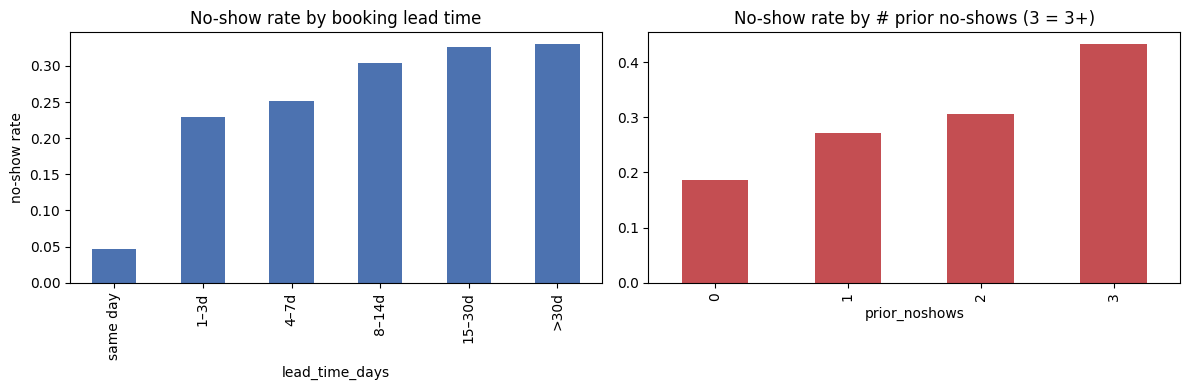

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) No-show rate vs how far ahead the appointment was booked
buckets = pd.cut(df["lead_time_days"], [-1, 0, 3, 7, 14, 30, 200],
                 labels=["same day", "1–3d", "4–7d", "8–14d", "15–30d", ">30d"])
df.groupby(buckets, observed=True)[LABEL].mean().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("No-show rate by booking lead time")
axes[0].set_ylabel("no-show rate")

# (b) No-show rate vs the patient's own track record (computed leakage-safe below,
#     but we can preview it with a quick history count)
tmp = add_history_features(df)
hist = tmp["prior_noshows"].clip(0, 3)
tmp.groupby(hist)[LABEL].mean().plot.bar(ax=axes[1], color="#C44E52")
axes[1].set_title("No-show rate by # prior no-shows (3 = 3+)")
plt.tight_layout()
plt.show()

Typical finding on the real data: same-day bookings almost always show up;
risk climbs steeply with lead time and with the patient's own no-show history.
This is why the rule baseline uses exactly these two signals.

## 3. Features (leakage-safe) and temporal split

Two rules, enforced in `src/features.py`:

1. `prior_*` features count only appointments strictly before the current one.
2. Test set = the last ~25% of appointment days. The model trains on the past
   and is judged on the future, exactly like deployment.

In [5]:
df = add_history_features(df)
train, test = temporal_split(df, test_frac=0.25)

X_train, y_train = train[FEATURES], train[LABEL]
X_test, y_test = test[FEATURES], test[LABEL]

# Sanity check the leakage guard: a patient's first-ever appointment must have zero history.
first_appts = df.groupby("patient_id").head(1)
assert (first_appts["prior_appointments"] == 0).all()
assert (first_appts["prior_noshows"] == 0).all()
print("Leakage guard passed: first appointments have zero history.")

temporal_split(): cutoff=2016-05-31  train=79788 rows (to 2016-05-30)  test=30728 rows (from 2016-05-31)
Leakage guard passed: first appointments have zero history.


## 4. How we keep score

- **k** = number of patients staff can call per test period (here: 20/day equivalent).
- **precision@k**: of the k we flag, how many truly no-show. This is the metric
  the office manager feels.
- **PR-AUC** for overall ranking quality on an imbalanced label. ROC-AUC for
  comparability with published studies.
- **Accuracy does not appear.** With an ~80/20 split it rewards predicting
  "everyone shows up".

In [6]:
n_test_days = test["appointment_day"].nunique()
K = 20 * n_test_days  # "20 calls per clinic day" scaled to the whole test window
print(f"Test window: {n_test_days} days -> k = {K} calls")

Test window: 7 days -> k = 140 calls


## 5. Baseline 1 — rules (no ML)

"Flag if the patient missed ≥2 appointments before, or booked >14 days ahead."

In [7]:
results = [evaluate_rule("rule baseline", y_test, rule_baseline(test), K)]
comparison_table(results)

,roc_auc,pr_auc,precision@140,recall@140,note
model,,,,,
rule baseline,None,None,0.286,0.514,"rule flags 10140 appts (own operating point, n..."


## 6. Baseline 2 — logistic regression

The field's workhorse (used in ~68% of published no-show studies). Linear,
fast, interpretable coefficients.

In [8]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), NUMERIC),
    ("bin", "passthrough", BINARY),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), CATEGORICAL),
])

logreg = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
])
logreg.fit(X_train, y_train)
lr_scores = logreg.predict_proba(X_test)[:, 1]
results.append(evaluate_scores("logistic regression", y_test, lr_scores, K))
comparison_table(results)

,roc_auc,pr_auc,precision@140,recall@140,note
model,,,,,
rule baseline,NaN,NaN,0.286,0.514,"rule flags 10140 appts (own operating point, n..."
logistic regression,0.681,0.314,0.536,0.013,NaN


## 7. Main model — LightGBM

Gradient-boosted trees: the strongest practical choice for tabular data.
Handles non-linear interactions (e.g. "long lead time matters more for young
patients") and missing values natively — no imputation needed.

In [9]:
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
for c in CATEGORICAL:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category")

lgbm = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=31,
    class_weight="balanced", random_state=42, verbose=-1,
)
lgbm.fit(X_train_lgb, y_train)
lgb_scores = lgbm.predict_proba(X_test_lgb)[:, 1]
results.append(evaluate_scores("lightgbm", y_test, lgb_scores, K))
comparison_table(results)

,roc_auc,pr_auc,precision@140,recall@140,note
model,,,,,
rule baseline,NaN,NaN,0.286,0.514,"rule flags 10140 appts (own operating point, n..."
logistic regression,0.681,0.314,0.536,0.013,NaN
lightgbm,0.730,0.346,0.621,0.015,NaN


## 8. What drives the predictions?

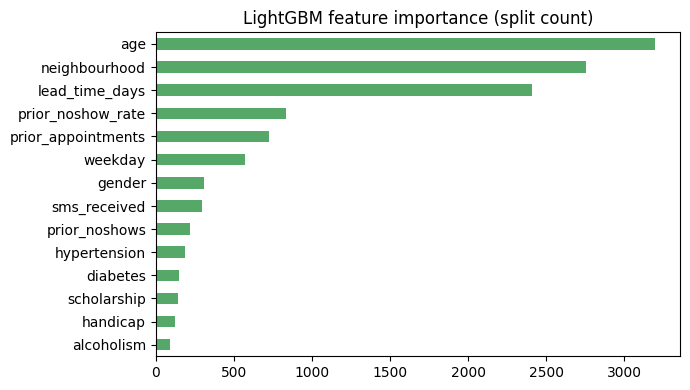

In [10]:
imp = pd.Series(lgbm.feature_importances_, index=X_train_lgb.columns).sort_values()
imp.plot.barh(figsize=(7, 4), color="#55A868", title="LightGBM feature importance (split count)")
plt.tight_layout()
plt.show()

## 9. Business translation — the slide that matters

Metrics don't convince office managers; recovered slots do. Every parameter
below is an explicit assumption — challenge them, don't hide them.

In [11]:
bv = business_value(y_test, lgb_scores, K)
for k_, v in bv.items():
    print(f"{k_:>28}: {v}")

                  calls_made: 140
        true_noshows_reached: 87.0
    expected_slots_recovered: 26.1
  expected_revenue_recovered: 5220.0
               outreach_cost: 700.0
                 assumptions: $200.0/slot, 30% of reached no-shows convert to attendance, $5.0/call


## 10. Conclusions and honest limitations

**Conclusions (real data, temporal split):**

- **LightGBM beat logistic regression by enough to matter:** ROC-AUC 0.730 vs 0.681,
  and precision@140 of 0.621 vs 0.536. At the clinic's call budget that difference is
  ~12 extra true no-shows caught per week, so the added complexity pays for itself.
  LightGBM is the model we carry forward.
- **Both models beat the rule baseline where it counts.** The rule flags 10,140
  appointments — a third of the test set, a call list no clinic can work — at 28.6%
  precision. The model compresses that into 140 targeted calls at 62.1% precision,
  3× the 20.2% base rate.
- **What it means at k=140:** if staff call the model's top 20 patients each day,
  ~12–13 of those calls reach true would-be no-shows. Over the 7-day test window that
  is ~87 no-shows reached → ~26 recovered slots → ~$5,220 recovered revenue against
  ~$700 outreach cost (assuming 30% of reached patients convert and $200/slot — both
  assumptions must be re-estimated per clinic).

**Limitations:** 6 weeks of history → most patients have no prior visits, so
`prior_*` features are sparse; retrospective ≠ prospective (published live
deployments lose AUC); intervention effect (does a call actually change
behavior?) is NOT measured here — that's uplift modeling, Level 3.

**Next (Level 2):** probability calibration, cost-sensitive threshold choice,
SHAP explanations per patient, Streamlit dashboard with the daily call list.
